In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression

In [103]:
df=pd.read_csv("Student_performance_data _.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [105]:
numerical_cols=df.select_dtypes(include=np.number).columns
print(numerical_cols)
df.isnull().sum()

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [107]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[numerical_cols]=scaler.fit_transform(df[numerical_cols])

In [109]:
for col in numerical_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lb=Q1-IQR*1.5
    ub=Q3+IQR*1.5
    df[col]=np.where(df[col]<lb,lb,df[col])
    df[col]=np.where(df[col]>ub,ub,df[col])
    
    

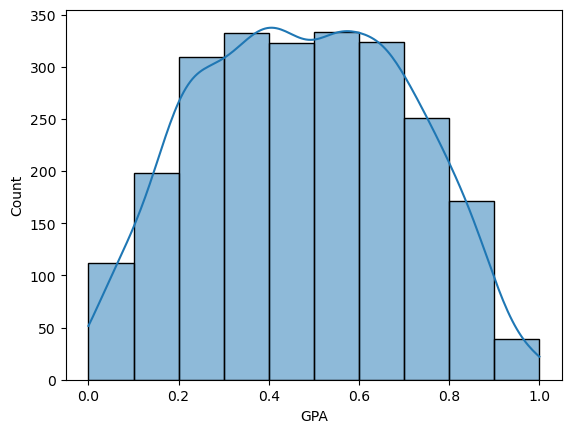

In [111]:
sns.histplot(df['GPA'],bins=10,kde=True)
plt.show()

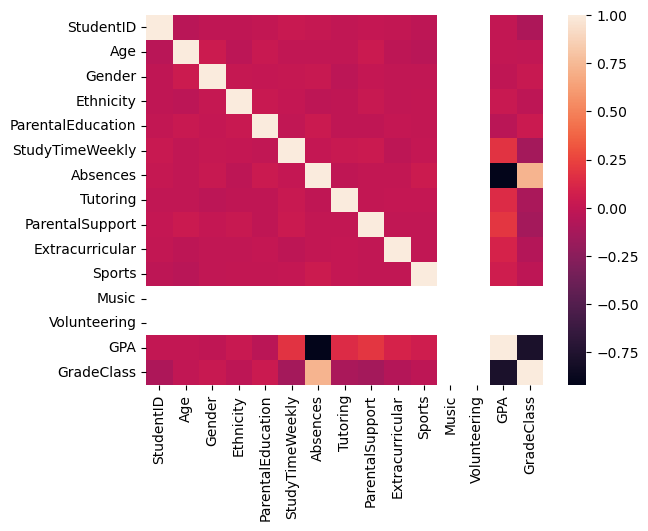

In [112]:
sns.heatmap(df.corr(),annot=False)
plt.show()

In [113]:
model=LinearRegression()
target='GPA'
corr=df[numerical_cols].corr()
corr_target=corr[target].abs()
selected_features = corr_target[corr_target >= 0.1].index.drop(target)
print("\nSelected Features (|corr| ≥ 0.21):")
print(list(selected_features))



Selected Features (|corr| ≥ 0.21):
['StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'GradeClass']


In [115]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

X=df[selected_features]
y=df[target]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred))
r2_multi = r2_score(y_test, y_pred)

print("\nMultivariable Regression Equation:")
print(f"y = {model.intercept_:.4f}", end="")
for f, c in zip(selected_features, model.coef_):
    print(f" + ({c:.4f})*{f}", end="")
print()

print("\nMultivariable Model Performance:")
print("RMSE :", rmse_multi)
print("R²   :", r2_multi)


Multivariable Regression Equation:
y = 0.7122 + (0.1339)*StudyTimeWeekly + (-0.6559)*Absences + (0.0597)*Tutoring + (0.1362)*ParentalSupport + (-0.0837)*GradeClass

Multivariable Model Performance:
RMSE : 0.05767411964030367
R²   : 0.9356406261919151


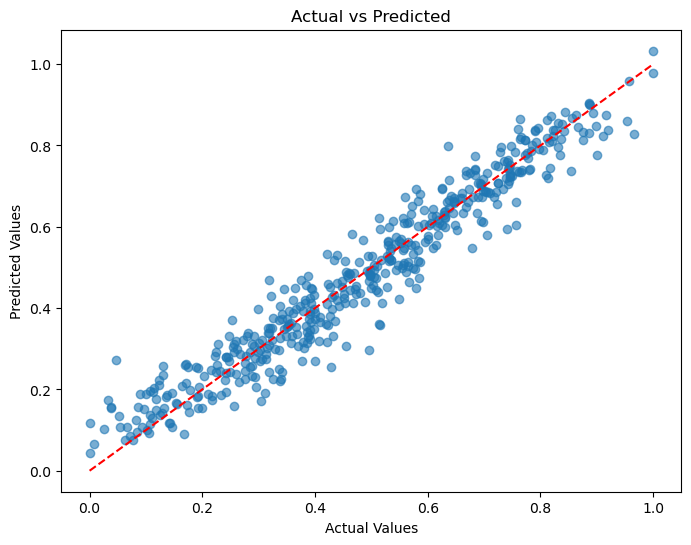

In [116]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [121]:
best_feature = 'Absences'
X_single=df[[best_feature]]
print(best_feature)
X_train,X_test, y_train,y_test= train_test_split(X_single,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred))
r2_single = r2_score(y_test, y_pred)

print("\nSingle Variable Regression Equation:")
print(f"y = {model.intercept_:.4f} + ({model.coef_[0]:.4f})*{best_feature}")

print("\nSingle Variable Model Performance:")
print("RMSE :", rmse_single)
print("R²   :", r2_single)

Absences

Single Variable Regression Equation:
y = 0.8380 + (-0.7196)*Absences

Single Variable Model Performance:
RMSE : 0.08869897184196539
R²   : 0.847774631744824


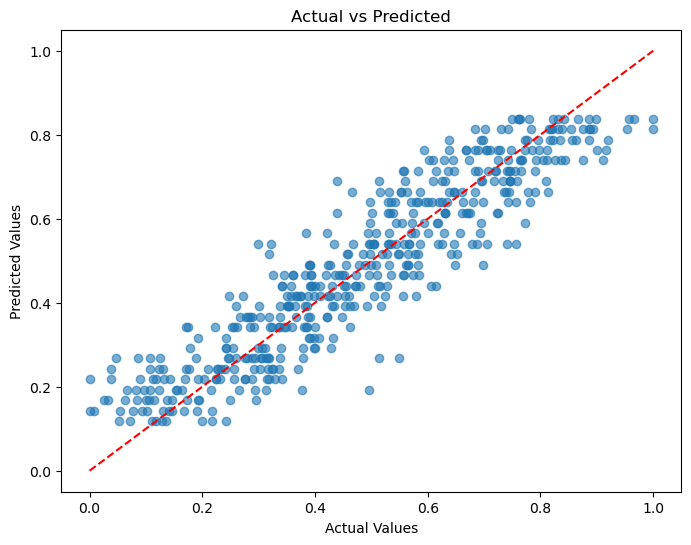

In [127]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
model2=LogisticRegression()